# **Handling missing data**

## **How you can handle missing data ???**

- By removing the entire row of the missing cell
    - also leads to the loss of additional cell data
- By imputing them 
    1. Univariate type
        - Depends on wheather the data is numerical or categorical
        - if numerical, can fill with mean, random num, end of distribution value
        - if categorical, can fill with mode, most frequent value
    2. Multivariate type
        - Two types
            - KNN imputer
            - Iterative imputer
            - MICE


## **CCA**
- CCA (complete case analysis) also called 'list-wise-deletion' of cases, consists in discarding observations where values variables are missing.
- CCA means literally analyzing only those observations for which there is info in all of the variables in the dataset.

### **Assumption for CCA**
- Data is missing completely at random (random implies data is missing at random places), its called **Missing Completely At Random (MCAR)**


#### **Advantages of Complete Case Analysis (CCA)**

- Very simple to implement  
  CCA (listwise deletion) just drops any row with missing values on the analysis variables, so it is easy to code, easy to explain, and is the default in many software packages.

- Uses standard complete‑data methods  
  After incomplete rows are removed, all usual models (regression, ANOVA, ML algorithms) can be applied without modification, which keeps analysis pipelines straightforward.

- Unbiased under MCAR  
  If data are Missing Completely At Random (MCAR), complete case analysis yields unbiased estimates of means, variances, and regression coefficients for the reduced sample.

- Preserves variable distribution. If data is MCAR, then the distribution of the variable of the reduced dataset should match the distribution in the original dataset.


#### **Disadvantages of Complete Case Analysis (CCA)**

- Loss of data and power  
  Dropping all rows with any missing value can remove a large fraction of the dataset, which reduces effective sample size and statistical power, especially when many variables are involved.

- Potentially serious bias  
  If missingness is not MCAR (for example, depends on the outcome or predictors), CCA can produce biased estimates and misleading conclusions because the analyzed subset is no longer representative.

- Inconsistent samples across analyses  
  Different models using different variable sets may each be based on different subsets of complete cases, making it hard to compare results and generalize findings.

- Inefficient use of available information  
  CCA discards partially observed rows that still contain useful information, whereas modern methods like multiple imputation or model‑based approaches can exploit these incomplete records.

- When using our models in production, the model will not know how to handle missing data

### **When to use ???**
- In case of MCAR
- In case of only 5% of data is missing, not more than that (generally used)



In [152]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [153]:
df = pd.read_csv('data_science_job.csv')
df.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0


In [154]:
print(df.shape)
print(f"\nThe unique values is the data are : \n\n{df.nunique()}\n")
print(f"\nThe missing data percentage is : \n\n{df.isna().mean()*100}")
# so we will be applying CCA where total number of missing data is less than 5%

(19158, 13)

The unique values is the data are : 

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   21
company_size                  8
company_type                  6
training_hours              241
target                        2
dtype: int64


The missing data percentage is : 

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64


In [155]:
cols = [i for i in df.columns 
        if df[i].isna().mean() < 0.05 and df[i].isna().mean() > 0]
print(f"COLUMNS LESS THEN 5 % MISSING VALUES ARE : \n{cols}\n\n")
print(f"WHAT PERCENTAGE OF DATA I WILL BE LEFT WITH AFTER REMOVING THE ROWS OF MISSING VALUES : \n\
{(len(df[cols].dropna()) / len(df))*100}")


# dropping the rows of the missing data
new_df = df[cols].dropna()
print(df.shape)
print(new_df.shape)
new_df.head(6)

COLUMNS LESS THEN 5 % MISSING VALUES ARE : 
['city_development_index', 'enrolled_university', 'education_level', 'experience', 'training_hours']


WHAT PERCENTAGE OF DATA I WILL BE LEFT WITH AFTER REMOVING THE ROWS OF MISSING VALUES : 
89.68577095730244
(19158, 13)
(17182, 5)


,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
6,0.920,no_enrollment,High School,5.0,24.0


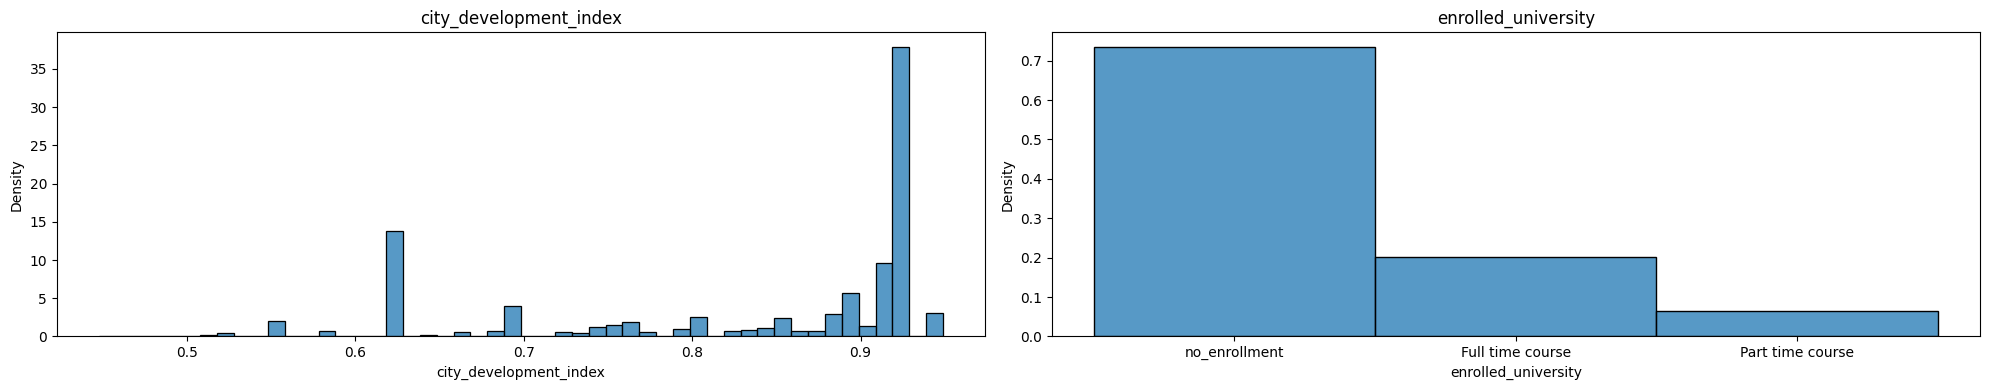

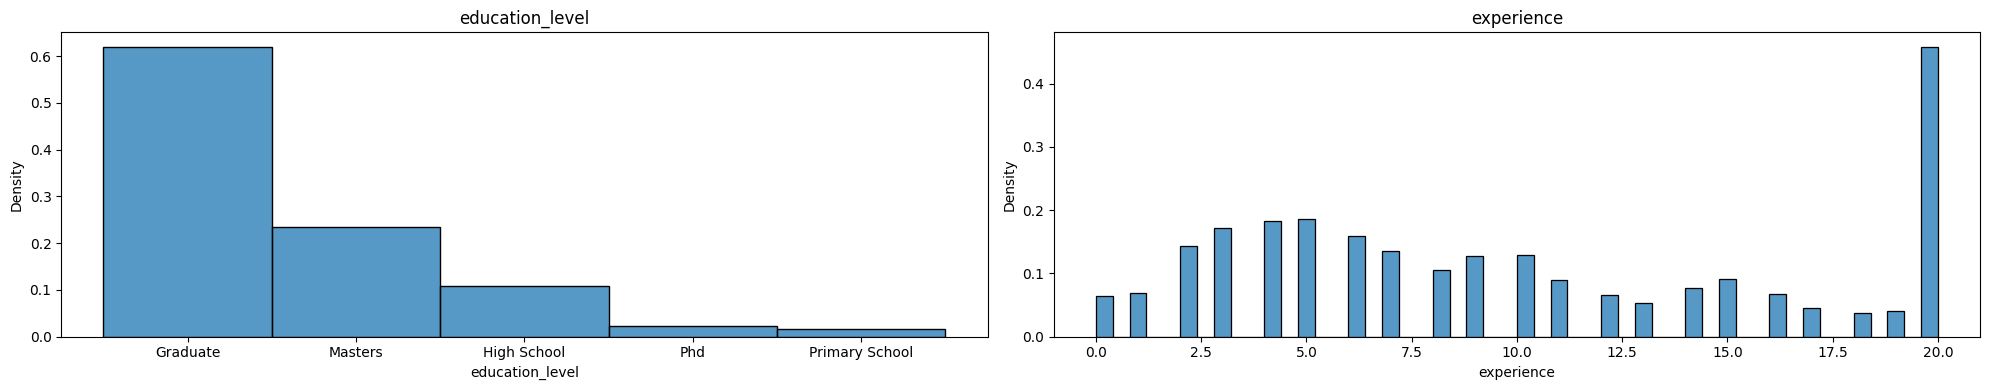

In [156]:
# Plotting the histogram of the new dataset
a = new_df.columns
for i in range(0, len(a)-1, 2):  # step by 2: (0,1), (2,3), ...
    plt.figure(figsize=(20, 4))

    # Left subplot: column i
    plt.subplot(1, 2, 1)
    sns.histplot(new_df[cols[i]], bins=50, stat='density')
    plt.title(a[i])

    # Right subplot: column i+1
    plt.subplot(1, 2, 2)
    sns.histplot(new_df[cols[i + 1]], bins=50, stat='density')
    plt.title(a[i+1])

    plt.tight_layout()
    plt.show()


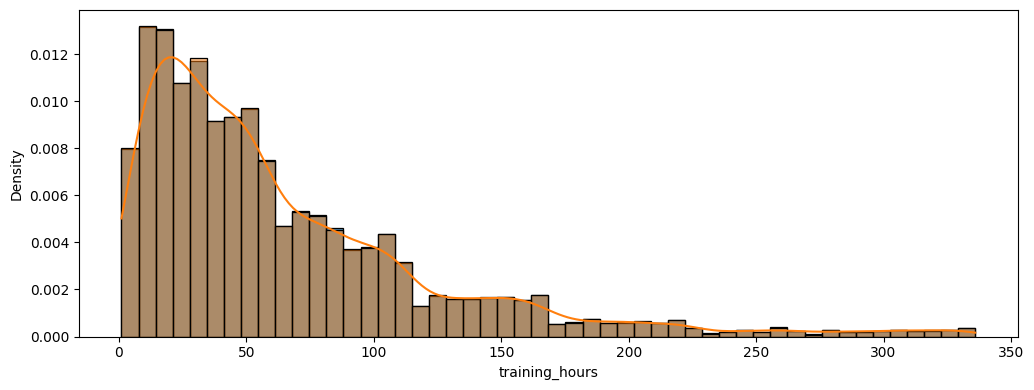

In [157]:
# comparing original data with new data
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.histplot(df['training_hours'], bins=50, stat='density')
# plt.subplot(122)
sns.histplot(new_df['training_hours'], bins=50, stat='density', kde=True)

plt.tight_layout()
plt.show()

# so here we have plotted two diagrams one over another, as you can see, both of the diagrams are same. This implies that loss of the data is minimal.



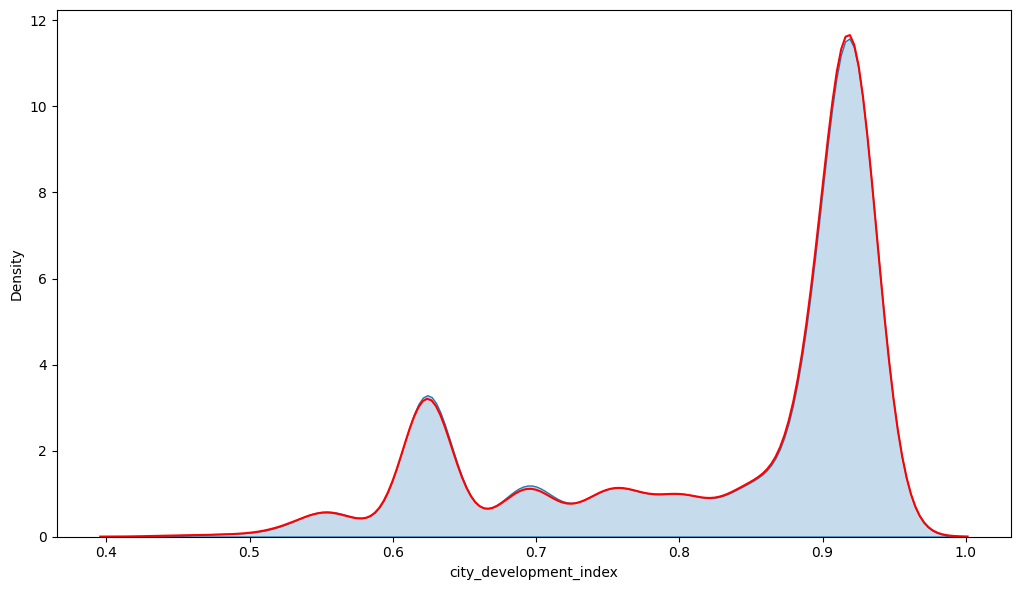

In [158]:
plt.figure(figsize=(20,6))
plt.subplot(121)
sns.kdeplot(df['city_development_index'], fill=True)
# plt.subplot(122)              # uncomment this line so that you can see the change is close to nothing
sns.kdeplot(new_df['city_development_index'], color='r')

plt.tight_layout()
plt.show()
# as you can see in the code below, there are some areas where the blue color has overlapped with the color red, these are the points where the datas has been removed in 'new_df'

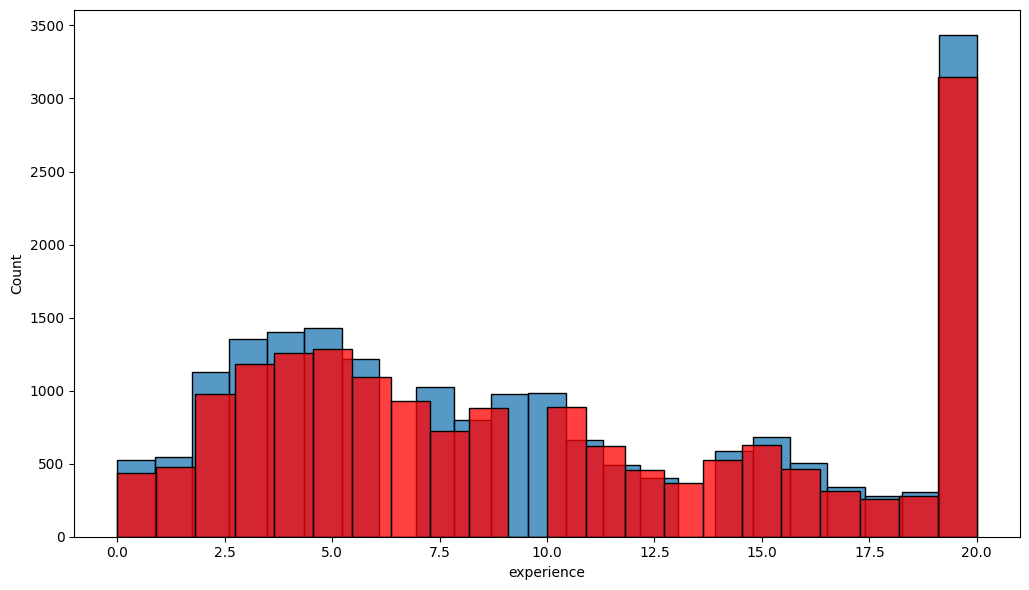

In [159]:
plt.figure(figsize=(20,6))
plt.subplot(121)
sns.histplot(df['experience'], fill=True)
# plt.subplot(122)              # uncomment this line so that you can see the change is close to nothing
sns.histplot(new_df['experience'], color='r')

plt.tight_layout()
plt.show()

# you can see the loss of data clearly in histplot

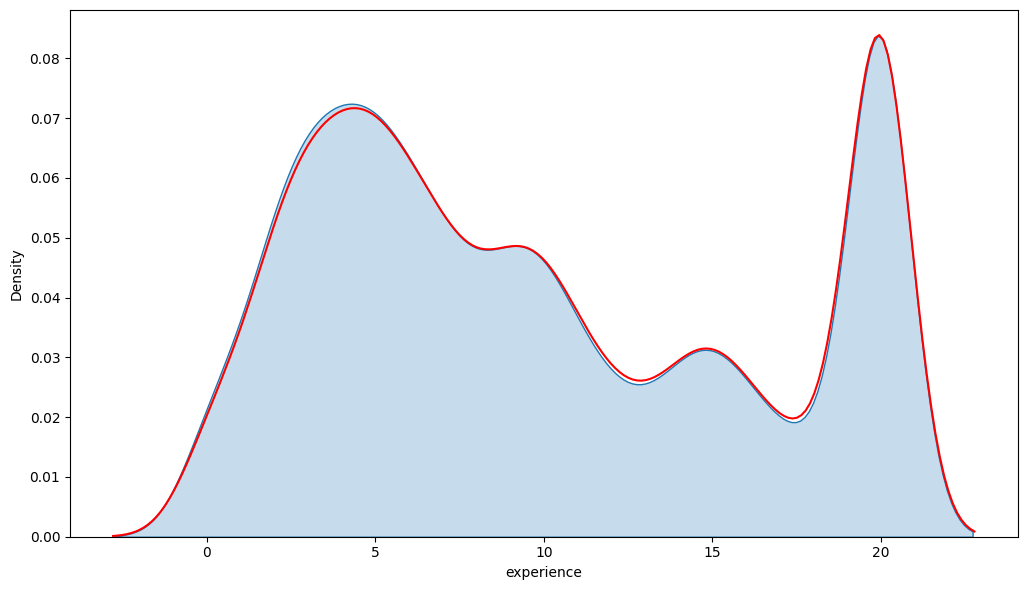

In [160]:
plt.figure(figsize=(20,6))
plt.subplot(121)
sns.kdeplot(df['experience'], fill=True)
# plt.subplot(122)              # uncomment this line so that you can see the change is close to nothing
sns.kdeplot(new_df['experience'], color='r')

plt.tight_layout()
plt.show()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64


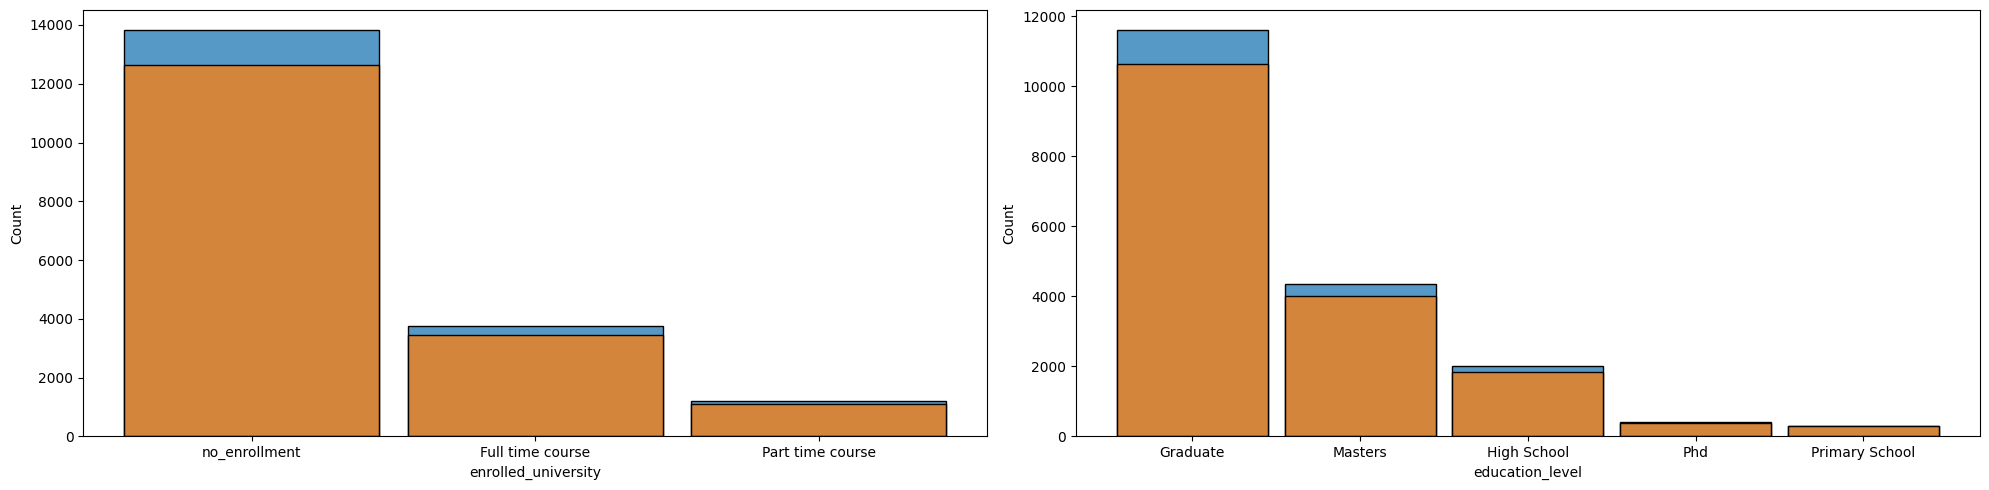

In [161]:
# enrolled_university and education_level are categorical variables
print(df['enrolled_university'].value_counts())
print()
print(df['education_level'].value_counts())

# plotting loss of data of each feature before and after CCA
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.histplot(df['enrolled_university'], shrink=0.9)         # shrink=0.9 is used to add space btwn the boxes
sns.histplot(new_df['enrolled_university'], shrink=0.9)

plt.subplot(1,2,2)
sns.histplot(df['education_level'], shrink=0.9)
sns.histplot(new_df['education_level'], shrink=0.9)
 

plt.tight_layout()
plt.show()

# you can see the loss of data clearly now for each category


In [162]:
print(df['enrolled_university'].value_counts())
print()
print(len(df))
print()
print(df['enrolled_university'].value_counts() / len(df))

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

19158

enrolled_university
no_enrollment       0.721213
Full time course    0.196106
Part time course    0.062533
Name: count, dtype: float64


In [ ]:
temp = pd.concat([
            df['enrolled_university'].value_counts() / len(df),             # len(df) -- total rows in df
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)


# add column names
temp.columns = ['original', 'cca']


temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [164]:
temp = pd.concat([
            df['education_level'].value_counts() / len(df),
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
